# 02d - Chignolin Joint Simulator + Tm Head

This notebook trains a single shared backbone end-to-end with two targets:
- frame-level simulator target (`dV`, plus optional auxiliary terms)
- mutant-level `Tm` prediction from the pooled trajectory of learned CVs

Model selection is done on validation `Tm` `R^2`, and the final report emphasizes test-set prediction against ground truth.

Current variant: the `Tm` branch trains jointly with the simulator, while checkpoint selection and early stopping use validation simulator loss.


In [23]:
# Requires: pip install -e .

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

from course_project.models.cv_tm_predictor import BackboneModel
from course_project.peptide import load_target_table
from course_project.peptide_tm import (
    build_train_val_test_split,
    metric_stats_from_train_mutants,
    prediction_stats,
    release_cuda_memory,
    run_sim_epoch,
)
from course_project.utils import resolve_device


### Config


In [24]:
device = torch.device(resolve_device('cuda'))
force_train = True
print('device:', device)

# Data
peptide_dir = Path('../data/peptide')
packed_path = peptide_dir / 'hlda_trajectories_compact.pt'
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'

num_runs = 1
train_mutant_count = 20
val_mutant_count = 8
exclude_mutants = {}

history = 1
frames_per_traj = 20000
take_every_kth_frame = 10

# Backbone
hidden_size = 96
CVs = 6
token_sizes = (450, 80, CVs)
heads = 1
transformer_layers = 1
pre_pyramid_layers = 1
linear_cv_decoder = True
dropout = 0.005
batch_size = 32
weight_decay = 0.0
cls_weight = 0.5
time_lag_steps = 0
time_lag_weight = 0.0

# Joint Tm head
metric_name = 'Tm'
tm_loss_weight = 3.0
metric_chunk_size = 32

# Training
learning_rate = 1e-4
epochs = 40
eval_every = 2
early_stop_patience = 4

run_name = 'chignolin_cv_joint_tm'
run_dir = Path('../results') / run_name
run_dir.mkdir(parents=True, exist_ok=True)
print('run dir:', run_dir)

target_df = load_target_table(tm_csv, mfpt_csv, evalue_csv)
target_mutants = set(target_df['mutant'].astype(str).tolist())

packed = torch.load(packed_path, weights_only=False)
x_all = packed['x'].float()
time_all = packed['time'].float()
offsets = packed['traj_offsets'].long()
labels = packed['labels'].long()
mutants = list(packed['mutants'])
n_feat = int(x_all.shape[1])

uniq_mutants = sorted({
    m for m in set(mutants)
    if str(m).strip().upper() not in exclude_mutants and str(m) in target_mutants
})
print('packed path:', packed_path)
print('feature count:', n_feat)
print('all usable mutants:', len(uniq_mutants))
print('train mutants:', train_mutant_count, 'val mutants:', val_mutant_count, 'test mutants:', len(uniq_mutants) - train_mutant_count - val_mutant_count)


device: cuda
run dir: ../results/chignolin_cv_joint_tm
packed path: ../data/peptide/hlda_trajectories_compact.pt
feature count: 29
all usable mutants: 37
train mutants: 20 val mutants: 8 test mutants: 9


### Helpers


In [25]:
class LinearTmHead(torch.nn.Module):
    def __init__(self, cv_dim: int):
        super().__init__()
        self.linear = torch.nn.Linear(cv_dim, 1)
        torch.nn.init.xavier_uniform_(self.linear.weight)
        torch.nn.init.zeros_(self.linear.bias)

    def forward(self, pooled_cv):
        return self.linear(pooled_cv).squeeze(-1)


def metric_value(mutant):
    row = target_df[target_df['mutant'].astype(str) == str(mutant)].iloc[0]
    return float(row[metric_name])


def scaled_metric(mutant, metric_stats):
    return (metric_value(mutant) - metric_stats['mean']) / metric_stats['std']


def build_metric_groups(sample_df, metric_stats):
    groups = []
    for mutant, grp in sample_df.reset_index(drop=True).groupby('mutant'):
        groups.append({
            'mutant': str(mutant),
            'indices': torch.tensor(grp.index.to_numpy(dtype=int), dtype=torch.long),
            'target_scaled': float(scaled_metric(mutant, metric_stats)),
            'target_value': float(metric_value(mutant)),
        })
    return groups


def mutant_batches(groups, batch_mutants, shuffle):
    order = list(range(len(groups)))
    if shuffle:
        random.shuffle(order)
    for start in range(0, len(order), batch_mutants):
        yield [groups[i] for i in order[start:start + batch_mutants]]


def pooled_tm_prediction(backbone, tm_head, x_tensor, indices, chunk_size, device, detach_backbone=True):
    cv_rows = []
    context = torch.no_grad() if detach_backbone else torch.enable_grad()
    with context:
        for start in range(0, len(indices), chunk_size):
            chunk_idx = indices[start:start + chunk_size]
            x_chunk = x_tensor[chunk_idx].to(device)
            cv_chunk = backbone.encode_cv(x_chunk)
            cv_rows.append(cv_chunk.detach() if detach_backbone else cv_chunk)
    cv_seq = torch.cat(cv_rows, dim=0)
    pooled_cv = cv_seq.mean(dim=0, keepdim=True)
    return tm_head(pooled_cv)


def run_tm_epoch(backbone, tm_head, x_tensor, groups, metric_stats, device, chunk_size, loss_weight, detach_backbone=True, opt=None):
    train_mode = opt is not None
    backbone.train(train_mode)
    tm_head.train(train_mode)
    total_loss = 0.0
    total_n = 0
    preds_value = []
    trues_value = []

    for item in groups if not train_mode else random.sample(groups, k=len(groups)):
        pred_scaled = pooled_tm_prediction(backbone, tm_head, x_tensor, item['indices'], chunk_size, device, detach_backbone=detach_backbone)
        target_scaled = torch.tensor(item['target_scaled'], dtype=torch.float32, device=device)
        loss = loss_weight * (pred_scaled - target_scaled).pow(2)
        if train_mode:
            opt.zero_grad()
            loss.backward()
            opt.step()
        pred_scaled_value = float(pred_scaled.detach().cpu().item())
        preds_value.append(pred_scaled_value * metric_stats['std'] + metric_stats['mean'])
        trues_value.append(float(item['target_value']))
        total_loss += float(loss.item())
        total_n += 1
        if train_mode:
            release_cuda_memory()

    pred_df = pd.DataFrame({metric_name: trues_value, f'pred_{metric_name}': preds_value})
    stats = prediction_stats(pred_df, metric_name)
    stats['metric_loss'] = total_loss / max(1, total_n)
    return stats


@torch.no_grad()
def predict_tm_df(backbone, tm_head, x_tensor, groups, metric_stats, device, chunk_size, detach_backbone=True):
    backbone.eval()
    tm_head.eval()
    rows = []
    for item in groups:
        pred_scaled = pooled_tm_prediction(backbone, tm_head, x_tensor, item['indices'], chunk_size, device, detach_backbone=detach_backbone)
        pred_value = float(pred_scaled.cpu().item()) * metric_stats['std'] + metric_stats['mean']
        rows.append({
            'mutant': item['mutant'],
            metric_name: item['target_value'],
            f'pred_{metric_name}': pred_value,
        })
    return pd.DataFrame(rows)


### Train


In [26]:
history_csv = run_dir / 'joint_history.csv'
summary_csv = run_dir / 'joint_prediction_summary.csv'
run_summary_csv = run_dir / 'run_summary.csv'
config_json = run_dir / 'config.json'

history_rows = []
summary_rows = []
run_rows = []
trained_payloads = []

need_train = force_train or not history_csv.exists() or not summary_csv.exists() or not run_summary_csv.exists()

if need_train:
    for run_idx in range(1, num_runs + 1):
        backbone_ckpt = run_dir / f'run_{run_idx:02d}_best.pt'
        train_pred_csv = run_dir / f'run_{run_idx:02d}_train_predictions.csv'
        val_pred_csv = run_dir / f'run_{run_idx:02d}_val_predictions.csv'
        test_pred_csv = run_dir / f'run_{run_idx:02d}_test_predictions.csv'

        run_seed = int(torch.seed() % (2**32 - 1))
        random.seed(run_seed)
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        split_payload = build_train_val_test_split(
            run_seed=run_seed,
            uniq_mutants=uniq_mutants,
            train_mutant_count=train_mutant_count,
            val_mutant_count=val_mutant_count,
            mutants=mutants,
            history=history,
            time_lag_steps=time_lag_steps,
            frames_per_traj=frames_per_traj,
            take_every_kth_frame=take_every_kth_frame,
            x_all=x_all,
            time_all=time_all,
            offsets=offsets,
            labels=labels,
            n_feat=n_feat,
        )
        metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, metric_name)
        train_groups = build_metric_groups(split_payload['train_samples_df'], metric_stats)
        val_groups = build_metric_groups(split_payload['val_samples_df'], metric_stats)
        test_groups = build_metric_groups(split_payload['test_samples_df'], metric_stats)

        release_cuda_memory()
        backbone = BackboneModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
            pre_pyramid_layers=pre_pyramid_layers,
            linear_cv_decoder=linear_cv_decoder,
        ).to(device)
        tm_head = LinearTmHead(CVs).to(device)

        opt = torch.optim.AdamW(
            list(backbone.parameters()) + list(tm_head.parameters()),
            lr=learning_rate,
            weight_decay=weight_decay,
        )

        train_loader = DataLoader(
            TensorDataset(split_payload['train_x'], split_payload['train_dv'], split_payload['train_dv_tau'], split_payload['train_cls']),
            batch_size=batch_size,
            shuffle=True,
            drop_last=False,
        )
        val_loader = DataLoader(
            TensorDataset(split_payload['val_x'], split_payload['val_dv'], split_payload['val_dv_tau'], split_payload['val_cls']),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

        best_epoch = 0
        best_val_r2 = float('-inf')
        best_val_loss = float('inf')
        best_val_sim_loss = float('inf')
        bad_epochs = 0

        for epoch in range(1, epochs + 1):
            tr_sim = run_sim_epoch(backbone, train_loader, device=device, time_lag_steps=time_lag_steps, time_lag_weight=time_lag_weight, cls_weight=cls_weight, opt=opt)
            release_cuda_memory()
            tr_tm = run_tm_epoch(backbone, tm_head, split_payload['train_x'], train_groups, metric_stats, device, metric_chunk_size, tm_loss_weight, opt=opt)
            va_sim = run_sim_epoch(backbone, val_loader, device=device, time_lag_steps=time_lag_steps, time_lag_weight=time_lag_weight, cls_weight=cls_weight, opt=None)
            release_cuda_memory()
            va_tm = run_tm_epoch(backbone, tm_head, split_payload['val_x'], val_groups, metric_stats, device, metric_chunk_size, tm_loss_weight, opt=None)

            history_rows.append({
                'run_idx': run_idx,
                'run_seed': run_seed,
                'epoch': epoch,
                **{f'train_sim_{k}': v for k, v in tr_sim.items()},
                **{f'train_tm_{k}': v for k, v in tr_tm.items()},
                **{f'val_sim_{k}': v for k, v in va_sim.items()},
                **{f'val_tm_{k}': v for k, v in va_tm.items()},
            })

            current_val_sim = float(va_sim['sim_loss'])
            if current_val_sim < best_val_sim_loss - 1e-8:
                best_val_sim_loss = current_val_sim
                best_val_r2 = float(va_tm['r2'])
                best_val_loss = float(va_tm['metric_loss'])
                best_epoch = epoch
                bad_epochs = 0
                torch.save({
                    'run_idx': run_idx,
                    'run_seed': run_seed,
                    'epoch': epoch,
                    'metric_stats': metric_stats,
                    'backbone_state_dict': backbone.state_dict(),
                    'tm_head_state_dict': tm_head.state_dict(),
                }, backbone_ckpt)
            else:
                bad_epochs += 1

            if epoch % eval_every == 0:
                print(
                    f'run {run_idx:02d} epoch {epoch:03d} | '
                    f'train sim={tr_sim["sim_loss"]:.4f} tm={tr_tm["metric_loss"]:.4f} R2={tr_tm["r2"]:.3f} | '
                    f'val sim={va_sim["sim_loss"]:.4f} tm={va_tm["metric_loss"]:.4f} R2={va_tm["r2"]:.3f} | '
                    f'best val sim={best_val_sim_loss:.4f} bad={bad_epochs}/{early_stop_patience}'
                )
            if bad_epochs >= early_stop_patience:
                print(f'run {run_idx:02d} early stop at epoch {epoch:03d} | best epoch={best_epoch:03d} val sim={best_val_sim_loss:.4f}')
                break

        best_payload = torch.load(backbone_ckpt, map_location='cpu', weights_only=False)
        metric_stats = best_payload['metric_stats']
        backbone.load_state_dict(best_payload['backbone_state_dict'])
        tm_head.load_state_dict(best_payload['tm_head_state_dict'])

        train_pred_df = predict_tm_df(backbone, tm_head, split_payload['train_x'], train_groups, metric_stats, device, metric_chunk_size)
        val_pred_df = predict_tm_df(backbone, tm_head, split_payload['val_x'], val_groups, metric_stats, device, metric_chunk_size)
        test_pred_df = predict_tm_df(backbone, tm_head, split_payload['test_x'], test_groups, metric_stats, device, metric_chunk_size)
        train_pred_df.to_csv(train_pred_csv, index=False)
        val_pred_df.to_csv(val_pred_csv, index=False)
        test_pred_df.to_csv(test_pred_csv, index=False)

        train_stats = prediction_stats(train_pred_df, metric_name)
        val_stats = prediction_stats(val_pred_df, metric_name)
        test_stats = prediction_stats(test_pred_df, metric_name)

        summary_rows.append({
            'run_idx': run_idx,
            'metric': metric_name,
            'train_n': train_stats['n'],
            'train_rmse': train_stats['rmse'],
            'train_mae': train_stats['mae'],
            'train_r2': train_stats['r2'],
            'train_pearson': train_stats['pearson'],
            'train_spearman': train_stats['spearman'],
            'val_n': val_stats['n'],
            'val_rmse': val_stats['rmse'],
            'val_mae': val_stats['mae'],
            'val_r2': val_stats['r2'],
            'val_pearson': val_stats['pearson'],
            'val_spearman': val_stats['spearman'],
            'test_n': test_stats['n'],
            'test_rmse': test_stats['rmse'],
            'test_mae': test_stats['mae'],
            'test_r2': test_stats['r2'],
            'test_pearson': test_stats['pearson'],
            'test_spearman': test_stats['spearman'],
        })
        run_rows.append({
            'run_idx': run_idx,
            'run_seed': run_seed,
            'best_epoch': best_epoch,
            'train_mutants': len(split_payload['train_mutants']),
            'val_mutants': len(split_payload['val_mutants']),
            'test_mutants': len(split_payload['test_mutants']),
        })
        trained_payloads.append({
            'run_idx': run_idx,
            'run_seed': run_seed,
            'train_pred_df': train_pred_df,
            'val_pred_df': val_pred_df,
            'test_pred_df': test_pred_df,
        })

        del backbone, tm_head, train_groups, val_groups, test_groups
        release_cuda_memory()

    history_df = pd.DataFrame(history_rows)
    summary_df = pd.DataFrame(summary_rows)
    run_summary_df = pd.DataFrame(run_rows)
    history_df.to_csv(history_csv, index=False)
    summary_df.to_csv(summary_csv, index=False)
    run_summary_df.to_csv(run_summary_csv, index=False)
    config_json.write_text(json.dumps({
        'train_mutant_count': train_mutant_count,
        'val_mutant_count': val_mutant_count,
        'frames_per_traj': frames_per_traj,
        'take_every_kth_frame': take_every_kth_frame,
        'hidden_size': hidden_size,
        'CVs': CVs,
        'token_sizes': list(token_sizes),
        'heads': heads,
        'transformer_layers': transformer_layers,
        'pre_pyramid_layers': pre_pyramid_layers,
        'batch_size': batch_size,
        'cls_weight': cls_weight,
        'tm_loss_weight': tm_loss_weight,
        'learning_rate': learning_rate,
        'epochs': epochs,
        'early_stop_patience': early_stop_patience,
    }, indent=2))
else:
    print('using existing run from', run_dir)
    history_df = pd.read_csv(history_csv)
    summary_df = pd.read_csv(summary_csv)
    run_summary_df = pd.read_csv(run_summary_csv)
    trained_payloads = []
    for _, row in run_summary_df.iterrows():
        run_idx = int(row['run_idx'])
        train_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_train_predictions.csv')
        val_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_val_predictions.csv')
        test_pred_df = pd.read_csv(run_dir / f'run_{run_idx:02d}_test_predictions.csv')
        trained_payloads.append({
            'run_idx': run_idx,
            'run_seed': int(row['run_seed']),
            'train_pred_df': train_pred_df,
            'val_pred_df': val_pred_df,
            'test_pred_df': test_pred_df,
        })

print('run summary:')
print(run_summary_df)
print('prediction summary:')
print(summary_df.round(3).to_string(index=False))


run 01 epoch 002 | train sim=0.9543 tm=8.3539 R2=-0.622 | val sim=0.9061 tm=14.3299 R2=-4.438 | best val sim=0.9061 bad=0/4
run 01 epoch 004 | train sim=0.9245 tm=9.2544 R2=-1.834 | val sim=0.9002 tm=4.3958 R2=-0.611 | best val sim=0.9002 bad=0/4
run 01 epoch 006 | train sim=0.9083 tm=15.8215 R2=-4.011 | val sim=0.9077 tm=6.9263 R2=-1.258 | best val sim=0.8959 bad=1/4
run 01 epoch 008 | train sim=0.8906 tm=4.7932 R2=-0.541 | val sim=0.8892 tm=2.1055 R2=0.160 | best val sim=0.8789 bad=1/4
run 01 epoch 010 | train sim=0.8782 tm=3.1809 R2=-0.027 | val sim=0.8946 tm=2.5372 R2=-0.021 | best val sim=0.8789 bad=3/4
run 01 early stop at epoch 011 | best epoch=007 val sim=0.8789
run summary:
   run_idx    run_seed  best_epoch  train_mutants  val_mutants  test_mutants
0        1  2041070905           7             20            8             9
prediction summary:
 run_idx metric  train_n  train_rmse  train_mae  train_r2  train_pearson  train_spearman  val_n  val_rmse  val_mae  val_r2  val_pearso

### Evaluation


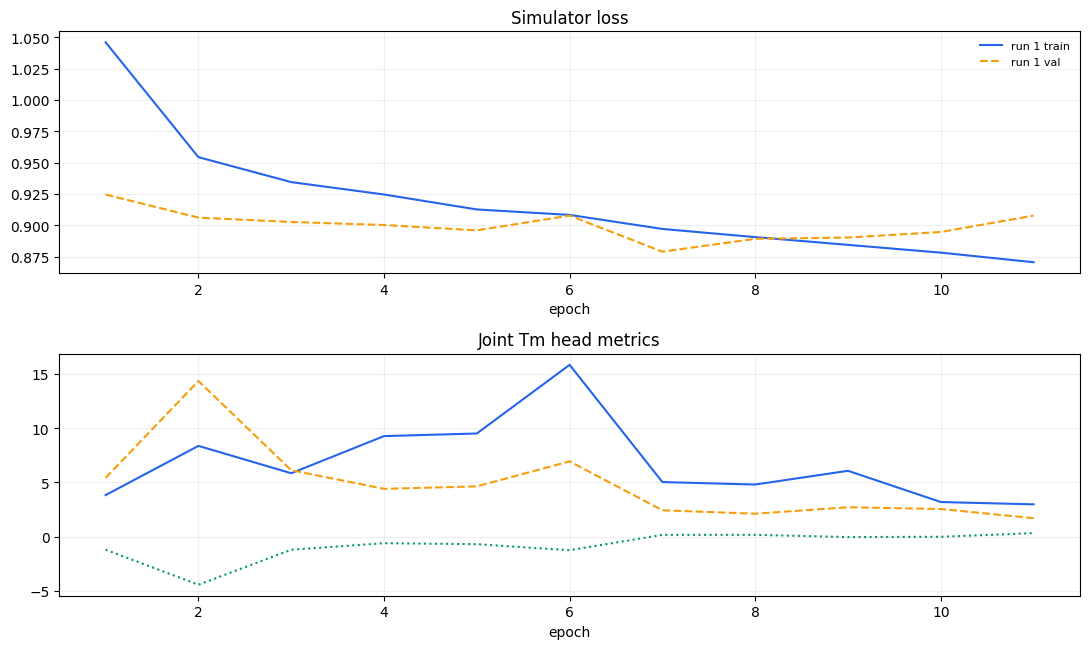

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), squeeze=False)
ax1, ax2 = axes[:, 0]
for run_idx, sub in history_df.groupby('run_idx'):
    sub = sub.sort_values('epoch')
    ax1.plot(sub['epoch'], sub['train_sim_sim_loss'], color='#2563eb', lw=1.5, label=f'run {run_idx} train')
    ax1.plot(sub['epoch'], sub['val_sim_sim_loss'], color='#f59e0b', lw=1.5, ls='--', label=f'run {run_idx} val')
ax1.set_title('Simulator loss')
ax1.set_xlabel('epoch')
ax1.grid(alpha=0.2)
ax1.legend(frameon=False, fontsize=8)

for run_idx, sub in history_df.groupby('run_idx'):
    sub = sub.sort_values('epoch')
    ax2.plot(sub['epoch'], sub['train_tm_metric_loss'], color='#2563eb', lw=1.5, label=f'run {run_idx} train loss')
    ax2.plot(sub['epoch'], sub['val_tm_metric_loss'], color='#f59e0b', lw=1.5, ls='--', label=f'run {run_idx} val loss')
    ax2.plot(sub['epoch'], sub['val_tm_r2'], color='#059669', lw=1.5, ls=':', label=f'run {run_idx} val R2')
ax2.set_title(f'Joint {metric_name} head metrics')
ax2.set_xlabel('epoch')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()


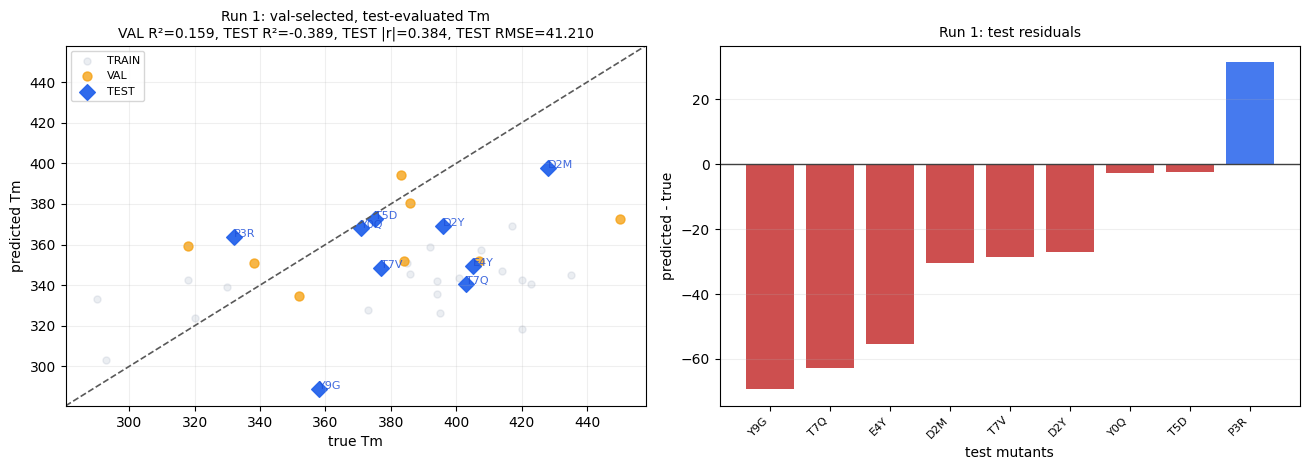

In [28]:
fig, axes = plt.subplots(len(trained_payloads), 2, figsize=(13.2, 4.8 * len(trained_payloads)), squeeze=False)
for row_i, payload in enumerate(trained_payloads):
    ax_scatter = axes[row_i, 0]
    ax_resid = axes[row_i, 1]
    train_df = payload['train_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()
    val_df = payload['val_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()
    test_df = payload['test_pred_df'][['mutant', metric_name, f'pred_{metric_name}']].copy()

    ax_scatter.scatter(train_df[metric_name], train_df[f'pred_{metric_name}'], s=26, alpha=0.18, color='#94a3b8', label='TRAIN')
    ax_scatter.scatter(val_df[metric_name], val_df[f'pred_{metric_name}'], s=42, alpha=0.75, color='#f59e0b', label='VAL')
    ax_scatter.scatter(test_df[metric_name], test_df[f'pred_{metric_name}'], s=64, alpha=0.95, color='#2563eb', marker='D', label='TEST')
    for _, rr in test_df.iterrows():
        ax_scatter.text(rr[metric_name], rr[f'pred_{metric_name}'], str(rr['mutant']), fontsize=8, alpha=0.84, color='#1d4ed8')
    combined = pd.concat([train_df[[metric_name, f'pred_{metric_name}']], val_df[[metric_name, f'pred_{metric_name}']], test_df[[metric_name, f'pred_{metric_name}']]], ignore_index=True)
    lo = float(np.nanmin(combined.to_numpy(dtype=float)))
    hi = float(np.nanmax(combined.to_numpy(dtype=float)))
    pad = 0.05 * (hi - lo + 1e-8)
    ax_scatter.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='0.35', lw=1.2, ls='--')
    ax_scatter.set_xlim(lo - pad, hi + pad)
    ax_scatter.set_ylim(lo - pad, hi + pad)
    val_stats = prediction_stats(val_df, metric_name)
    test_stats = prediction_stats(test_df, metric_name)
    title = f'Run {payload["run_idx"]}: val-selected, test-evaluated {metric_name}'
    title += '\n'
    title += f'VAL R²={val_stats["r2"]:.3f}, TEST R²={test_stats["r2"]:.3f}, TEST |r|={abs(test_stats["pearson"]):.3f}, TEST RMSE={test_stats["rmse"]:.3f}'
    ax_scatter.set_title(title, fontsize=10)
    ax_scatter.set_xlabel(f'true {metric_name}')
    ax_scatter.set_ylabel(f'predicted {metric_name}')
    ax_scatter.grid(alpha=0.2)
    ax_scatter.legend(loc='best', fontsize=8)

    resid_df = test_df.copy()
    resid_df['residual'] = resid_df[f'pred_{metric_name}'] - resid_df[metric_name]
    resid_df = resid_df.sort_values('residual').reset_index(drop=True)
    colors = ['#c53030' if val < 0 else '#2563eb' for val in resid_df['residual']]
    ax_resid.bar(range(len(resid_df)), resid_df['residual'], color=colors, alpha=0.85)
    ax_resid.axhline(0.0, color='0.25', lw=1.0)
    ax_resid.set_title(f'Run {payload["run_idx"]}: test residuals', fontsize=10)
    ax_resid.set_xlabel('test mutants')
    ax_resid.set_ylabel('predicted - true')
    ax_resid.set_xticks(range(len(resid_df)))
    ax_resid.set_xticklabels(resid_df['mutant'], rotation=45, ha='right', fontsize=8)
    ax_resid.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()


In [29]:
summary_df.sort_values(['val_r2', 'test_r2', 'test_rmse'], ascending=[False, False, True]).round(3)


,run_idx,metric,train_n,train_rmse,train_mae,train_r2,train_pearson,train_spearman,val_n,val_rmse,val_mae,val_r2,val_pearson,val_spearman,test_n,test_rmse,test_mae,test_r2,test_pearson,test_spearman
0,1,Tm,20,56.242,49.838,-0.568,0.49,0.327,8,39.304,31.589,0.159,0.368,0.31,9,41.21,34.44,-0.389,0.384,0.267
